loaded spectral data named 'imx477' from 400.0nm to 700.0nm
loaded spectral data named 'imx477_rpi' from 280.0nm to 800.0nm


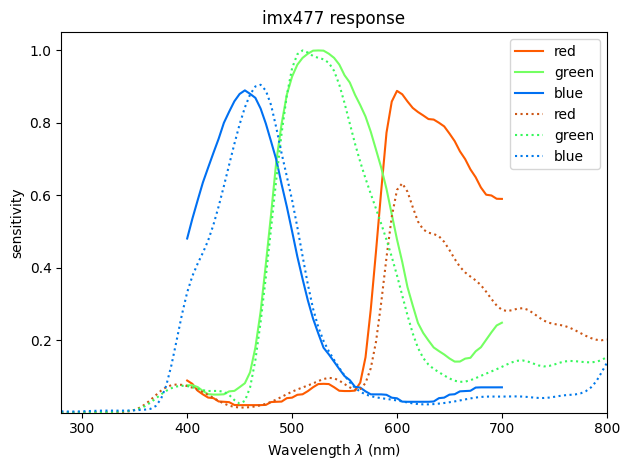

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'imx477 response'}, xlabel='Wavelength $\\lambda$ (nm)', ylabel='sensitivity'>)

In [35]:
import numpy as np
import colour

colour.set_domain_range_scale("1")
from pathlib import Path


def load_image_sensor_response(filename):
    array = np.genfromtxt(filename, delimiter=",", skip_header=1)
    data = {row[0]: row[1:] for row in array}
    msd = colour.MultiSpectralDistributions(
        data, labels=["red", "green", "blue"], name=Path(filename).stem
    )
    print(
        f"loaded spectral data named '{msd.name}' from {msd.wavelengths[0]}nm to {msd.wavelengths[-1]}nm"
    )
    return msd / np.max(msd.values)


plot_kwargs = {"use_sd_colours": True}
plot_kwargs_individual = []
for linestyle in ["solid", "dotted"]:
    plot_kwargs_individual += ([{**plot_kwargs, "linestyle": linestyle}] * 3)
colour.plotting.plot_multi_sds(
    [
        load_image_sensor_response("imx477.csv"),
        load_image_sensor_response("imx477_rpi.csv"),
    ],
    plot_kwargs=plot_kwargs_individual,
    y_label="sensitivity",
    title=f"imx477 response",
)